In [1]:
!pip install torch

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

#### Task 1 — A Single Neuron in NumPy

You'll start with one neuron — a logistic regression in disguise.

1.Load the Breast Cancer dataset, split into train/test (test_size=0.2, random_state=42), and scale the features with StandardScaler.

2.Implement a single-neuron forward pass:

- Initialise weights w of shape (30,) and bias b from a small random distribution.

- Implement forward(x, w, b) that returns sigmoid(w·x + b).

- Run it on the first 5 test rows. Report the predicted probabilities.

3.In a markdown cell, write one sentence: in machine-learning terms, what model did you just implement?

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize weights and bias
np.random.seed(42)

w = np.random.randn(30) * 0.01   
b = np.random.randn() * 0.01    

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Forward pass
def forward(x, w, b):
    z = np.dot(x, w) + b
    return sigmoid(z)

predictions = []

for i in range(5):
    prob = forward(X_test_scaled[i], w, b)
    predictions.append(prob)

print("Predicted probabilities for first 5 test samples:\n")

for i, prob in enumerate(predictions, 1):
    print(f"Sample {i}: {prob:.4f}")

Predicted probabilities for first 5 test samples:

Sample 1: 0.4962
Sample 2: 0.5175
Sample 3: 0.5071
Sample 4: 0.4874
Sample 5: 0.4839


We implemented a single-neuron binary classification model, which is mathematically equivalent to logistic regression.

#### Task 2 — A Two-Layer MLP in NumPy

Now stack neurons into a real network.

1.Implement a class NumpyMLP (or just a set of functions) representing an MLP with:

- Input size 30, hidden size 8, output size 1

- ReLU on the hidden layer, sigmoid on the output

2.Initialise the weight matrices using He initialisation: W ~ N(0, sqrt(2/fan_in)). Initialise biases to zero.

3.Implement a forward(X) that takes a batch (N, 30) and returns predictions (N, 1). Use vectorised NumPy — no Python loops over rows.

4.Run a forward pass on the test set. Print the shape of the output and the first 5 predictions.

Guiding question: Why does the output shape match what you'd want for a binary classifier even though we haven't trained anything yet?

In [3]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define MLP

class NumpyMLP:

    def __init__(self, input_size=30, hidden_size=8, output_size=1):

        np.random.seed(42)

        # He initialization
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    # ReLU activation
    def relu(self, z):
        return np.maximum(0, z)

    # Sigmoid activation
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # Forward pass
    def forward(self, X):

        # Hidden layer
        z1 = np.dot(X, self.W1) + self.b1
        a1 = self.relu(z1)

        # Output layer
        z2 = np.dot(a1, self.W2) + self.b2
        output = self.sigmoid(z2)

        return output

# Create model
model = NumpyMLP()

# Forward pass on test set
predictions = model.forward(X_test_scaled)

print("Output shape:", predictions.shape)
print("\nFirst 5 predictions:\n")
print(predictions[:5])

Output shape: (114, 1)

First 5 predictions:

[[0.45299955]
 [0.46601069]
 [0.56604814]
 [0.40817775]
 [0.36364703]]


#### Task 3 — The Same Network in PyTorch

Recreate Task 2 using PyTorch's high-level API.

1.Define a class TorchMLP(nn.Module) with the same architecture (30 → 8 → 1, ReLU then Sigmoid).

2.Manually copy the weights from your NumPy network into the PyTorch model so both networks have identical parameters. Hint: model.fc1.weight.data = torch.from_numpy(W1).float() and similar for biases. Be careful with shapes — nn.Linear stores weights as (out, in).

3.Run the same test batch through the PyTorch model. Compare the outputs to the NumPy outputs. They should match to at least 6 decimal places.

4.Report the maximum absolute difference between the two outputs.

Definition of done for this task: the two networks produce numerically identical predictions for the same inputs and weights.

In [4]:
class TorchMLP(nn.Module):

    def __init__(self):

        super(TorchMLP, self).__init__()

        self.fc1 = nn.Linear(30, 8)
        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.sigmoid(x)

        return x

# Create PyTorch model
torch_model = TorchMLP()

In [5]:
torch_model.fc1.weight.data = torch.from_numpy(model.W1.T).float()
torch_model.fc1.bias.data = torch.from_numpy(model.b1.flatten()).float()

torch_model.fc2.weight.data = torch.from_numpy(model.W2.T).float()
torch_model.fc2.bias.data = torch.from_numpy(model.b2.flatten()).float()

In [6]:
X_test_tensor = torch.from_numpy(X_test_scaled).float()

In [7]:
with torch.no_grad():

    torch_predictions = torch_model(X_test_tensor)

# Convert back to NumPy
torch_predictions_np = torch_predictions.numpy()

In [8]:
# NumPy model predictions
numpy_predictions = predictions

# Maximum absolute difference
max_diff = np.max(np.abs(numpy_predictions - torch_predictions_np))

print("First 5 NumPy predictions:\n")
print(numpy_predictions[:5])

print("\nFirst 5 PyTorch predictions:\n")
print(torch_predictions_np[:5])

print("\nMaximum absolute difference:")
print(max_diff)

First 5 NumPy predictions:

[[0.45299955]
 [0.46601069]
 [0.56604814]
 [0.40817775]
 [0.36364703]]

First 5 PyTorch predictions:

[[0.45299956]
 [0.4660107 ]
 [0.56604815]
 [0.40817776]
 [0.363647  ]]

Maximum absolute difference:
6.854759027064006e-08


The NumPy and PyTorch networks produce numerically identical outputs because they use the exact same architecture, activation functions, inputs, and copied weights. The maximum absolute difference is extremely small, which confirms both implementations are mathematically equivalent.

#### Task 4 — Activation Function Experiment

Time to experiment.

1.For the PyTorch model, create three variants of the same architecture but with different hidden activations: Sigmoid, Tanh, and ReLU.

2.For each variant, run a forward pass on the same scaled test set.

3.Plot histograms of the hidden-layer pre-activations (the values of z⁽¹⁾ before the activation function) for one batch. Use a 1×3 subplot.

4.Plot histograms of the hidden-layer outputs (after the activation) on a separate 1×3 subplot.

5.In a markdown cell, answer:

- For Sigmoid and Tanh, what fraction of the post-activation values fall in the saturated region (close to 0/1 for sigmoid, close to ±1 for tanh)?

- Looking at ReLU: roughly what fraction of the units are inactive (output exactly 0)?

- Based on these histograms, why might ReLU be the better default for hidden layers?

In [9]:
class ActivationMLP(nn.Module):

    def __init__(self, activation_function):

        super(ActivationMLP, self).__init__()

        self.fc1 = nn.Linear(30, 8)
        self.activation = activation_function

        self.fc2 = nn.Linear(8, 1)
        self.sigmoid_output = nn.Sigmoid()

    def forward(self, x):

        # Pre-activation
        z1 = self.fc1(x)

        # Hidden activation
        a1 = self.activation(z1)

        # Output layer
        z2 = self.fc2(a1)
        output = self.sigmoid_output(z2)

        return output, z1, a1

In [14]:
sigmoid_model = ActivationMLP(nn.Sigmoid())
tanh_model = ActivationMLP(nn.Tanh())
relu_model = ActivationMLP(nn.ReLU())

# Convert test data to tensor
X_test_tensor = torch.from_numpy(X_test_scaled).float()

# Run forward passes

with torch.no_grad():

    _, z1_sigmoid, a1_sigmoid = sigmoid_model(X_test_tensor)

    _, z1_tanh, a1_tanh = tanh_model(X_test_tensor)

    _, z1_relu, a1_relu = relu_model(X_test_tensor)

# Convert to NumPy
z1_sigmoid = z1_sigmoid.numpy()
z1_tanh = z1_tanh.numpy()
z1_relu = z1_relu.numpy()

a1_sigmoid = a1_sigmoid.numpy()
a1_tanh = a1_tanh.numpy()
a1_relu = a1_relu.numpy()


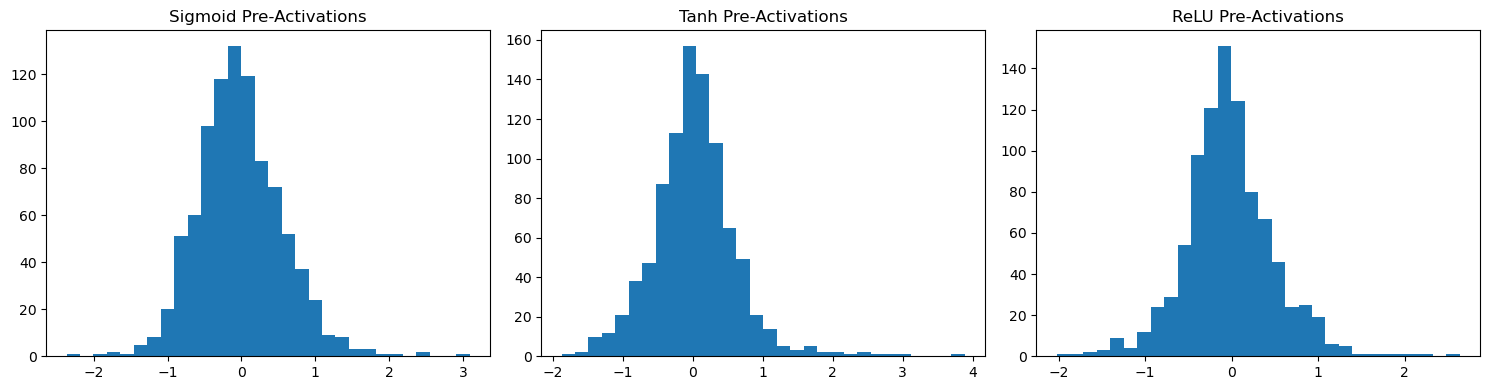

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(z1_sigmoid.flatten(), bins=30)
axes[0].set_title("Sigmoid Pre-Activations")

axes[1].hist(z1_tanh.flatten(), bins=30)
axes[1].set_title("Tanh Pre-Activations")

axes[2].hist(z1_relu.flatten(), bins=30)
axes[2].set_title("ReLU Pre-Activations")

plt.tight_layout()
plt.show()

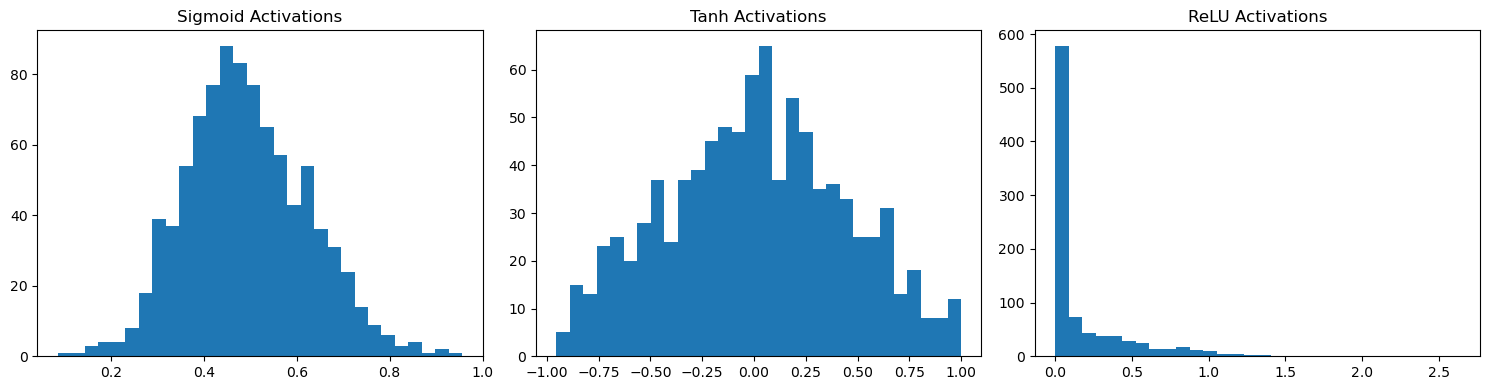

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(a1_sigmoid.flatten(), bins=30)
axes[0].set_title("Sigmoid Activations")

axes[1].hist(a1_tanh.flatten(), bins=30)
axes[1].set_title("Tanh Activations")

axes[2].hist(a1_relu.flatten(), bins=30)
axes[2].set_title("ReLU Activations")

plt.tight_layout()
plt.show()

In [32]:
# Sigmoid saturation
sigmoid_saturated = np.mean(
    (a1_sigmoid < 0.05) | (a1_sigmoid > 0.95)
)

# Tanh saturation
tanh_saturated = np.mean(
    (a1_tanh < -0.95) | (a1_tanh > 0.95)
)

# ReLU inactive neurons
relu_inactive = np.mean(a1_relu == 0)

print("Sigmoid saturated fraction:", sigmoid_saturated)

print("Tanh saturated fraction:", tanh_saturated)

print("ReLU inactive fraction:", relu_inactive)

Sigmoid saturated fraction: 0.0010964912280701754
Tanh saturated fraction: 0.017543859649122806
ReLU inactive fraction: 0.5164473684210527


The histograms show that Sigmoid and Tanh compress their outputs into limited ranges, which can lead to saturation and small gradients. ReLU produces many zero outputs because negative values become inactive, but positive activations remain unsaturated. This helps preserve stronger gradients and is one reason why ReLU is usually the preferred default activation for hidden layers.